# Loading & Plotting Plate Model

Geological reconstruction is the process of reversing tectonic plate movements to visualize how Earth's surface appeared in the past. By applying plate motion models, we can "rewind" the positions of coastlines, continents, plate boundaries, and fossil locations to understand ancient geography and geological processes.

### Setup

Let's begin by importing the required packages:

In [18]:
# Ensure you have the required packages installed:
# Run `pip install gplately matplotlib` if not already installed.

import gplately
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from plate_model_manager import PlateModelManager

Now, let's use gplately's `PlateModelManager` to create a plate reconstruction model based on the Müller et al. (2019) global plate model, [“A Global Plate Model Including Lithospheric Deformation Along Major Rifts and Orogens Since the Triassic”](https://www.earthbyte.org/muller-et-al-2019-deforming-plate-reconstruction-and-seafloor-age-grids-tectonics/).

> `NOTE:` You can also load a plate model through local files on your system!

In [19]:
# Create a Plate Model Manager
pm_manager = PlateModelManager()

# Load & download model data into the path specified by 'data_dir'
# To load a specific model, you can specify the model name
try:
    muller2019_model = pm_manager.get_model("Muller2019", data_dir="../../data/plate-model-repo")
except Exception as e:
    print(f"Error loading model: {e}")

# Fetch components of the loaded model
rotation_model_2019 = muller2019_model.get_rotation_model()
topology_features_2019 = muller2019_model.get_topologies()
static_polygons_2019 = muller2019_model.get_static_polygons()

model = gplately.PlateReconstruction(rotation_model_2019, topology_features_2019, static_polygons_2019)

# Coastlines, Continental polygons and COBs
coastlines = muller2019_model.get_layer('Coastlines')
continents = muller2019_model.get_layer('ContinentalPolygons')
COBs = muller2019_model.get_layer('COBs')

# Create PlotTopologies object
gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=continents, COBs=COBs)

time = 200  # Ma

### Plotting Coastlines

This code reconstructs and plots what Earth’s coastlines looked like in the past (here, 200 million years ago), using GPlately’s `PlotTopologies` object.

- Set up the map: We create a Matplotlib figure with a Cartopy PlateCarree projection, which is perfect for displaying global geographic data.

- Choose the time: We tell GPlately to look back 200 Ma by setting `gplot.time = time`. Here, gplot is a `PlotTopologies` object that takes care of reconstructing geological features to the chosen time.

- Plot coastlines: We call `plot_coastlines()` to draw the reconstructed shorelines, shown as black lines. These positions are calculated automatically from the plate motion model.

- Add map details: Finally, we set the global view, add axis labels, a title, and draw a coordinate grid so the map is easy to read.

The great thing about `PlotTopologies` is that it handles all the heavy lifting: it applies the plate motion model and moves the coastlines back through time for you. That way, you can quickly see how Earth’s geography has changed over millions of years!

To learn more about its capabilities check out the [GPlately documentation on PlotTopologies](https://gplates.github.io/gplately/latest/sphinx/html/generated/gplately.PlotTopologies.html)

> Note: Before running this, make sure your gplot object is properly set up (as done in the above snippet) and always set gplot.time before calling any plotting methods.

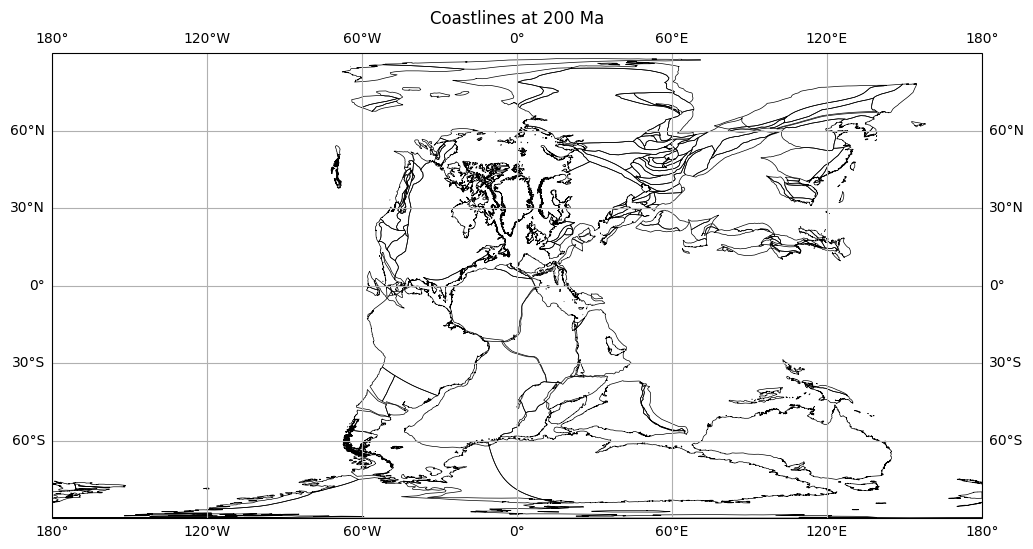

In [20]:
# Set up a GeoAxes with PlateCarree projection
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set the reconstruction time
gplot.time = time

# Plot coastlines reconstructed at 'time'
gplot.plot_coastlines(
    ax=ax,
    color='black',
    linewidth=0.5
)

# Set plot extent, labels & title
ax.set_global()
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Coastlines at {time} Ma')
ax.gridlines(draw_labels=True)

plt.show()

### Plotting Coastlines With Plate Boundaries

Let’s see another example, this time plotting both reconstructed coastlines and plate boundaries at 200 Ma.

- Set the time: As before, we set `gplot.time = time` to reconstruct features back to 200 Ma.

- Plot coastlines: Use `plot_coastlines()` to draw ancient shorelines as black lines.

- Plot boundaries: Add `plot_all_topological_sections()` to show ridges, transforms, and subduction zones, usually in a contrasting color like red.

- Finalize the map: Set the global extent, labels, title, and gridlines for clarity.

This way, you can see not just the ancient landmasses, but also how tectonic plate boundaries were arranged at the time.

Once again, check the [GPlately documentation on PlotTopologies](https://gplates.github.io/gplately/latest/sphinx/html/generated/gplately.PlotTopologies.html) if you’d like to dive deeper!

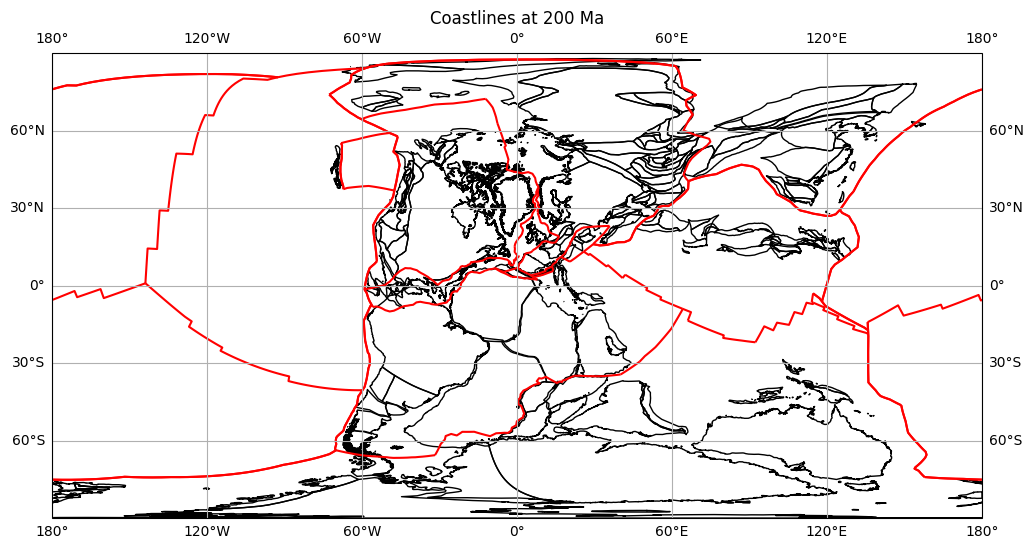

In [21]:
# Set up a GeoAxes with PlateCarree projection
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set the reconstruction time
gplot.time = time

# Plot coastlines
gplot.plot_coastlines(ax=ax, color='black')

# Plot plate boundaries (all sections: ridges, transforms, subduction)
gplot.plot_all_topological_sections(ax=ax, color='red')

# Set plot extent, labels & title
ax.set_global()
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Coastlines at {time} Ma')
ax.gridlines(draw_labels=True)

plt.show()
